In [19]:
import matplotlib
import pyneb as pn

import numpy as np
import matplotlib.pyplot as plt
import astropy
from astropy.io import fits
from scipy.interpolate import Akima1DInterpolator
from scipy import optimize as opt
import sys
import emcee
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from astropy.table import Table

from astropy.table import Table
import numpy as np
from astropy.table import join
import matplotlib.pyplot as plt
from astropy.table import join
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table, vstack


The UNICORN catalogs use nJy for flux units, so magnitudes are -2.5*np.log10(FLUX_F277W/3631e9). That will give a better idea of the range of brightnesses that we are seeing.

In [3]:
CEERS_magnitude = Table.read('ceers_photom_v0.6.fits')
CEERS_227 = CEERS_magnitude['FLUX_F277W']
RUBIES_magnitude = Table.read('primeruds_photom_v0.5.fits')
RUBIES_227 = RUBIES_magnitude['FLUX_F277W']
magnitude_table = Table.read("../Capstone Project/ceers_photom_v0.5.fits")
RUBIES_and_CEERS_table = Table.read('MASTER_RUBIES_AND_CEERS_TABLE.fits')

In [4]:
RUBIES_and_CEERS_table

filename,rest_frame_wavelength,flux,redshift,flux_error,flags,ra,dec,wavelength,flux_lambda,flux_error_lambda,catalog,obs_wavelength_in_ang,rest_frame_wavelength_in_ang,flux_lambda_cleaned,flux_error_lambda_cleaned,rest_frame_wavelength_cleaned,obs_wavelength_cleaned,flux_intrinsic,flux_error_corrected,dust_corrected,ratios,which_ratio,new_rubies_redshifts,new_restframe_in_ang,F277W,ratio_84th,dust_correction_flag
bytes72,object,object,float64,object,bool,float64,float64,object,object,object,bytes6,object,object,object,object,object,object,object,object,bytes3,float64,bytes6,float64,object,float64,float64,bool
hlsp_ceers_jwst_nirspec_nirspec10-000023_comb-mgrat_v0.7_x1d-masked.fits,[0.13646702 0.13655724 0.13664746 ... 0.73018126 0.73043525 0.73068925],[ 0. 0. nan ... nan nan nan],6.0512736702065855,[nan nan nan ... nan nan nan],True,214.876469,52.839412,[0.96226629 0.96290248 0.96353867 ... 5.14870789 5.15049887 5.15228984],[ 0. 0. nan ... nan nan nan],[nan nan nan ... nan nan nan],CEERS,[ 9622.66289288 9629.02477967 9635.38667652 ... 51487.07892761\n 51504.98867357 51522.8983846 ],[1364.67017775 1365.57241004 1366.47464376 ... 7301.8125995 7304.35253012\n 7306.8924558 ],[ 0. 0. nan ... nan nan nan],[nan nan nan ... nan nan nan],[1364.67017775 1365.57241004 1366.47464376 ... 7301.8125995 7304.35253012\n 7306.8924558 ],[ 9622.66289288 9629.02477967 9635.38667652 ... 51487.07892761\n 51504.98867357 51522.8983846 ],[ 0. 0. nan ... nan nan nan],[nan nan nan ... nan nan nan],Yes,4.013046941902093,Halpha,6.0512736702065855,[1364.67017775 1365.57241004 1366.47464376 ... 7301.8125995 7304.35253012\n 7306.8924558 ],27.361566445612876,4.013046941902093,True
hlsp_ceers_jwst_nirspec_nirspec10-000024_comb-mgrat_v0.7_x1d-masked.fits,[0.12564756 0.12572675 0.12580594 ... 0.65776864 0.65799001 0.65821138],[nan nan nan ... nan nan nan],7.0308386300914645,[nan nan nan ... nan nan nan],True,214.839316,52.882565,[1.00905527 1.00969124 1.01032721 ... 5.28243381 5.2842116 5.28598937],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],CEERS,[10090.55268918 10096.91241293 10103.27210842 ... 52824.33807727\n 52842.11595644 52859.89370483],[1256.47558791 1257.26750069 1258.05940995 ... 6577.68640492 6579.90010638\n 6582.11379155],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[1256.47558791 1257.26750069 1258.05940995 ... 6577.68640492 6579.90010638\n 6582.11379155],[10090.55268918 10096.91241293 10103.27210842 ... 52824.33807727\n 52842.11595644 52859.89370483],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],Yes,1.8528751380770774,Hgamma,7.0308386300914645,[1256.47558791 1257.26750069 1258.05940995 ... 6577.68640492 6579.90010638\n 6582.11379155],28.182391588608642,1.8528751380770774,True
hlsp_ceers_jwst_nirspec_nirspec10-000515_comb-mgrat_v0.7_x1d-masked.fits,[0.14382026 0.1439111 0.14400194 ... 0.7543949 0.75464883 0.75490275],[nan nan nan ... nan nan nan],6.002401236437165,[nan nan nan ... nan nan nan],True,214.836197,52.882693,[1.00708719 1.00772326 1.00835934 ... 5.2825758 5.28435387 5.28613193],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],CEERS,[10070.87186006 10077.23263077 10083.59337318 ... 52825.75799174\n 52843.53869368 52861.31926507],[1438.20262793 1439.11099786 1440.01936375 ... 7543.94902664 7546.48825587\n 7549.02746647],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],[1438.20262793 1439.11099786 1440.01936375 ... 7543.94902664 7546.48825587\n 7549.02746647],[10070.87186006 10077.23263077 10083.59337318 ... 52825.75799174\n 52843.53869368 52861.31926507],[nan nan nan ... nan nan nan],[nan nan nan ... nan nan nan],Yes,2.726175284619157,Halpha,6.002401236437165,[1438.20262793 1439.11099786 1440.01936375 ... 7543.94902664 7546.48825587\n 7549.02746647],25.26174308252525,2.726175284619157,True
hlsp_ceers_jwst_nirspec_nirspec10-000618_comb-mgrat_v0.7_x1d-masked.fits,[0.15349724 0.15359826 0.15369928 ... 0.84247839 0.84276021 0.84304202],[nan nan nan ... nan nan nan],5.27035783674

## check where PRIMER-UDS and CEERS-FULL sources lie in RUBIES full data set

In [5]:
# contains_primer_uds = np.array(['PRIMER-UDS' in filename for filename in RUBIES_and_CEERS_table['filename']])
# indices = np.where(contains_primer_uds)
# len(indices[0])

# contains_ceers_full = np.array(['CEERS-FULL' in filename for filename in RUBIES_and_CEERS_table['filename']])
# indices = np.where(contains_ceers_full)
# len(indices[0])

## ra/dec merge of PRIMER-UDS

In [6]:
# primer_uds_indices = np.where(contains_primer_uds)[0]
# filtered_table = RUBIES_and_CEERS_table[primer_uds_indices]

# # Create SkyCoord objects for cross-matching
# ceers_coords = SkyCoord(ra=filtered_table['ra']*u.deg, dec=filtered_table['dec']*u.deg)
# magnitude_coords = SkyCoord(ra=RUBIES_magnitude['RA']*u.deg, dec=RUBIES_magnitude['DEC']*u.deg)

# # Perform cross-matching
# idx, d2d, _ = ceers_coords.match_to_catalog_sky(magnitude_coords)
# max_sep = 1 * u.arcsec  
# sep_constraint = d2d < max_sep

# # Create a new table with the matched entries
# matched_table = filtered_table[sep_constraint]
# matched_table['matched_index'] = idx[sep_constraint]
# matched_table['separation'] = d2d[sep_constraint].to(u.arcsec)

# # Append the matched magnitude data
# for col in RUBIES_magnitude.columns:
#     if col not in ['RA', 'DEC']:  # Optionally skip appending RA and DEC
#         matched_table[col + '_matched'] = RUBIES_magnitude[col][idx[sep_constraint]]

# # Now matched_table contains all the information from the RUBIES table and the matched magnitude data


## ra/dec merge of CEERS-FULL

In [7]:
# ceers_full_indices = np.where(contains_ceers_full)[0]
# filtered_ceers_table = RUBIES_and_CEERS_table[ceers_full_indices]

# # Create SkyCoord objects for cross-matching
# ceers_coords_ceers = SkyCoord(ra=filtered_ceers_table['ra']*u.deg, dec=filtered_ceers_table['dec']*u.deg)
# magnitude_coords_ceers = SkyCoord(ra=CEERS_magnitude['RA']*u.deg, dec=CEERS_magnitude['DEC']*u.deg)

# # Perform cross-matching
# idx_ceers, d2d_ceers, _ = ceers_coords_ceers.match_to_catalog_sky(magnitude_coords_ceers)
# max_sep_ceers = 1 * u.arcsec  
# sep_constraint_ceers = d2d_ceers < max_sep_ceers

# # Create a new table with the matched entries
# matched_table_ceers = filtered_ceers_table[sep_constraint_ceers]
# matched_table_ceers['matched_index'] = idx_ceers[sep_constraint_ceers]
# matched_table_ceers['separation'] = d2d_ceers[sep_constraint_ceers].to(u.arcsec)

# # Append the matched magnitude data from CEERS
# for col in CEERS_magnitude.columns:
#     if col not in ['RA', 'DEC']:  # Optionally skip appending RA and DEC
#         matched_table_ceers[col + '_matched'] = CEERS_magnitude[col][idx_ceers[sep_constraint_ceers]]

# # Combine matched tables from PRIMER-UDS and CEERS-FULL
# from astropy.table import vstack
# combined_matched_table = vstack([matched_table, matched_table_ceers])

# # Now combined_matched_table contains all the information from the RUBIES table matched with both PRIMER-UDS and CEERS-FULL magnitude data


## magnitudes of CEERS & RUBIES

In [8]:
# Filtering for PRIMER-UDS
contains_primer_uds = np.array(['PRIMER-UDS' in filename for filename in RUBIES_and_CEERS_table['filename']])
primer_uds_indices = np.where(contains_primer_uds)[0]
filtered_primer_table = RUBIES_and_CEERS_table[primer_uds_indices]
primer_coords = SkyCoord(ra=filtered_primer_table['ra']*u.deg, dec=filtered_primer_table['dec']*u.deg)
primer_mag_coords = SkyCoord(ra=RUBIES_magnitude['RA']*u.deg, dec=RUBIES_magnitude['DEC']*u.deg)
idx_primer, d2d_primer, _ = primer_coords.match_to_catalog_sky(primer_mag_coords)
max_sep_primer = 1 * u.arcsec  
sep_constraint_primer = d2d_primer < max_sep_primer
matched_table = filtered_primer_table[sep_constraint_primer]
matched_table['matched_index'] = idx_primer[sep_constraint_primer]
matched_table['separation'] = d2d_primer[sep_constraint_primer].to(u.arcsec)
for col in RUBIES_magnitude.columns:
    if col not in ['RA', 'DEC']:
        matched_table[col + '_matched'] = RUBIES_magnitude[col][idx_primer[sep_constraint_primer]]

# Filtering for CEERS-FULL
contains_ceers_full = np.array(['CEERS-FULL' in filename for filename in RUBIES_and_CEERS_table['filename']])
ceers_full_indices = np.where(contains_ceers_full)[0]
filtered_ceers_table = RUBIES_and_CEERS_table[ceers_full_indices]
ceers_coords = SkyCoord(ra=filtered_ceers_table['ra']*u.deg, dec=filtered_ceers_table['dec']*u.deg)
ceers_mag_coords = SkyCoord(ra=CEERS_magnitude['RA']*u.deg, dec=CEERS_magnitude['DEC']*u.deg)
idx_ceers, d2d_ceers, _ = ceers_coords.match_to_catalog_sky(ceers_mag_coords)
sep_constraint_ceers = d2d_ceers < max_sep_primer
matched_table_ceers = filtered_ceers_table[sep_constraint_ceers]
matched_table_ceers['matched_index'] = idx_ceers[sep_constraint_ceers]
matched_table_ceers['separation'] = d2d_ceers[sep_constraint_ceers].to(u.arcsec)
for col in CEERS_magnitude.columns:
    if col not in ['RA', 'DEC']:
        matched_table_ceers[col + '_matched'] = CEERS_magnitude[col][idx_ceers[sep_constraint_ceers]]

# Filtering for 'nirspec'
contains_nirspec = np.array(['nirspec' in filename.lower() for filename in RUBIES_and_CEERS_table['filename']])
nirspec_indices = np.where(contains_nirspec)[0]
filtered_nirspec_table = RUBIES_and_CEERS_table[nirspec_indices]
nirspec_coords = SkyCoord(ra=filtered_nirspec_table['ra']*u.deg, dec=filtered_nirspec_table['dec']*u.deg)
nirspec_mag_coords = SkyCoord(ra=magnitude_table['RA']*u.deg, dec=magnitude_table['DEC']*u.deg)
idx_nirspec, d2d_nirspec, _ = nirspec_coords.match_to_catalog_sky(nirspec_mag_coords)
sep_constraint_nirspec = d2d_nirspec < max_sep_primer
matched_table_nirspec = filtered_nirspec_table[sep_constraint_nirspec]
matched_table_nirspec['matched_index'] = idx_nirspec[sep_constraint_nirspec]
matched_table_nirspec['separation'] = d2d_nirspec[sep_constraint_nirspec].to(u.arcsec)
for col in magnitude_table.columns:
    if col not in ['RA', 'DEC']:
        matched_table_nirspec[col + '_matched'] = magnitude_table[col][idx_nirspec[sep_constraint_nirspec]]

# Combine all matched tables
combined_matched_table = vstack([matched_table, matched_table_ceers, matched_table_nirspec])


In [9]:
combined_matched_table

filename,rest_frame_wavelength,flux,redshift,flux_error,flags,ra,dec,wavelength,flux_lambda,flux_error_lambda,catalog,obs_wavelength_in_ang,rest_frame_wavelength_in_ang,flux_lambda_cleaned,flux_error_lambda_cleaned,rest_frame_wavelength_cleaned,obs_wavelength_cleaned,flux_intrinsic,flux_error_corrected,dust_corrected,ratios,which_ratio,new_rubies_redshifts,new_restframe_in_ang,F277W,ratio_84th,dust_correction_flag,matched_index,separation,ID_matched,COORDID_matched,DETECTCAT_matched,X_matched,Y_matched,XMIN_matched,XMAX_matched,YMIN_matched,YMAX_matched,KRON_RADIUS_matched,A_IMAGE_matched,B_IMAGE_matched,THETA_IMAGE_matched,APCORR_matched,APCORR_APER_matched,APCORR_WINGS_matched,STELLARITY_matched,ISOAREA_IMAGE_matched,D_APER_matched,STARFLAGS_matched,DEPTHTIER_matched,APERFLAGS_matched,SCALE_KRON_matched,SCALE_MODEL_matched,FLUX_F435W_matched,FLUXERR_F435W_matched,FLUX_KRON_F435W_matched,FLUXERR_KRON_F435W_matched,FLUX_APER_F435W_matched,FLUX_APER_NATIVE_F435W_matched,FLUXERR_APER_F435W_matched,FLUX_APERTOT_F435W_matched,FLUXERR_APERTOT_F435W_matched,RH_F435W_matched,FWHM_F435W_matched,FLUXERR_LOCAL_F435W_matched,EDGEFLAGS_51PIX_F435W_matched,EDGEFLAGS_21PIX_F435W_matched,FLUX_F606W_matched,FLUXERR_F606W_matched,FLUX_KRON_F606W_matched,FLUXERR_KRON_F606W_matched,FLUX_APER_F606W_matched,FLUX_APER_NATIVE_F606W_matched,FLUXERR_APER_F606W_matched,FLUX_APERTOT_F606W_matched,FLUXERR_APERTOT_F606W_matched,RH_F606W_matched,FWHM_F606W_matched,FLUXERR_LOCAL_F606W_matched,EDGEFLAGS_51PIX_F606W_matched,EDGEFLAGS_21PIX_F606W_matched,FLUX_F814W_matched,FLUXERR_F814W_matched,FLUX_KRON_F814W_matched,FLUXERR_KRON_F814W_matched,FLUX_APER_F814W_matched,FLUX_APER_NATIVE_F814W_matched,FLUXERR_APER_F814W_matched,FLUX_APERTOT_F814W_matched,FLUXERR_APERTOT_F814W_matched,RH_F814W_matched,FWHM_F814W_matched,FLUXERR_LOCAL_F814W_matched,EDGEFLAGS_51PIX_F814W_matched,EDGEFLAGS_21PIX_F814W_matched,FLUX_F125W_matched,FLUXERR_F125W_matched,FLUX_KRON_F125W_matched,FLUXERR_KRON_F125W_matched,FLUX_APER_F125W_matched,FLUX_APER_NATIVE_F125W_matched,FLUXERR_APER_F125W_matched,FLUX_APERTOT_F125W_matched,FLUXERR_APERTOT_F125W_matched,RH_F125W_matched,FWHM_F125W_matched,FLUXERR_LOCAL_F125W_matched,EDGEFLAGS_51PIX_F125W_matched,EDGEFLAGS_21PIX_F125W_matched,FLUX_F140W_matched,FLUXERR_F140W_matched,FLUX_KRON_F140W_matched,FLUXERR_KRON_F140W_matched,FLUX_APER_F140W_matched,FLUX_APER_NATIVE_F140W_matched,FLUXERR_APER_F140W_matched,FLUX_APERTOT_F140W_matched,FLUXERR_APERTOT_F140W_matched,RH_F140W_matched,FWHM_F140W_matched,FLUXERR_LOCAL_F140W_matched,EDGEFLAGS_51PIX_F140W_matched,EDGEFLAGS_21PIX_F140W_matched,FLUX_F160W_matched,FLUXERR_F160W_matched,FLUX_KRON_F160W_matched,FLUXERR_KRON_F160W_matched,FLUX_APER_F160W_matched,FLUX_APER_NATIVE_F160W_matched,FLUXERR_APER_F160W_matched,FLUX_APERTOT_F160W_matched,FLUXERR_APERTOT_F160W_matched,RH_F160W_matched,FWHM_F160W_matched,FLUXERR_LOCAL_F160W_matched,EDGEFLAGS_51PIX_F160W_matched,EDGEFLAGS_21PIX_F160W_matched,FLUX_F090W_matched,FLUXERR_F090W_matched,FLUX_KRON_F090W_matched,FLUXERR_KRON_F090W_matched,FLUX_APER_F090W_matched,FLUX_APER_NATIVE_F090W_matched,FLUXERR_APER_F090W_matched,FLUX_APERTOT_F090W_matched,FLUXERR_APERTOT_F090W_matched,RH_F090W_matched,FWHM_F090W_matched,FLUXERR_LOCAL_F090W_matched,EDGEFLAGS_51PIX_F090W_matched,EDGEFLAGS_21PIX_F090W_matched,FLUX_F115W_matched,FLUXERR_F115W_matched,FLUX_KRON_F115W_matched,FLUXERR_KRON_F115W_matched,FLUX_APER_F115W_matched,FLUX_APER_NATIVE_F115W_matched,FLUXERR_APER_F115W_matched,FLUX_APERTOT_F115W_matched,FLUXERR_APERTOT_F115W_matched,RH_F115W_matched,FWHM_F115W_matched,FLUXERR_LOCAL_F115W_matched,EDGEFLAGS_51PIX_F115W_matched,EDGEFLAGS_21PIX_F115W_matched,FLUX_F150W_matched,FLUXERR_F150W_matched,FLUX_KRON_F150W_matched,FLUXERR_KRON_F150W_matched,FLUX_APER_F150W_matched,FLUX_APER_NATIVE_F150W_matched,FLUXERR_APER_F150W_matched,FLUX_APERTOT_F150W_matched,FLUXERR_APERTOT_F150W_matched,RH_F150W_matched,FWHM_F150W_matched,FLUXERR_LOCAL_F150W_matched,EDGEFLAGS_51PIX_F150W_matche

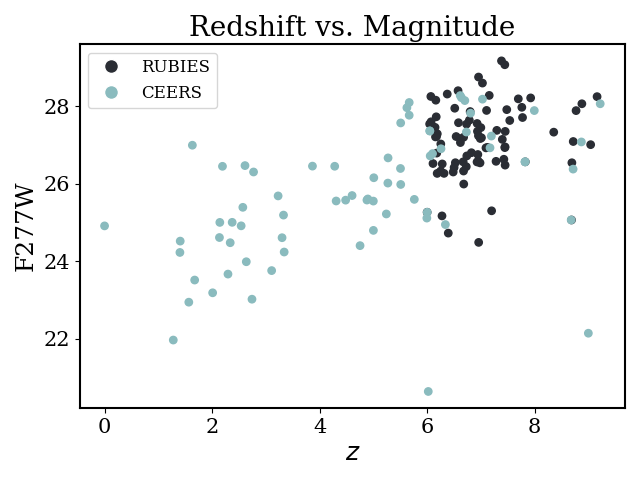

In [20]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib widget
plt.figure()
plt.style.use('paper')  # Ensure this style exists or use 'default'
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['axes.linewidth'] = 1.5

# Calculate the flux
flux = -2.5 * np.log10(combined_matched_table['FLUX_F277W_matched'] / 3631e9)

# Create a color array based on the 'which_catalog' values
colors = np.where(combined_matched_table['catalog'] == 'RUBIES', '#2A2D34', '#8ABBBE')

# Plotting
plt.scatter(combined_matched_table['redshift'], flux, c=colors, label={'RUBIES': '#8ABBBE', 'CEERS': '#2A2D34 '},s = 28)
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#2A2D34', markersize=10, label='RUBIES'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#8ABBBE', markersize=10, label='CEERS')
])
plt.title('Redshift vs. Magnitude')
plt.xlabel('$z$')
plt.ylabel('F277W')
plt.tight_layout()
plt.subplots_adjust(bottom=0.15) 
plt.show()


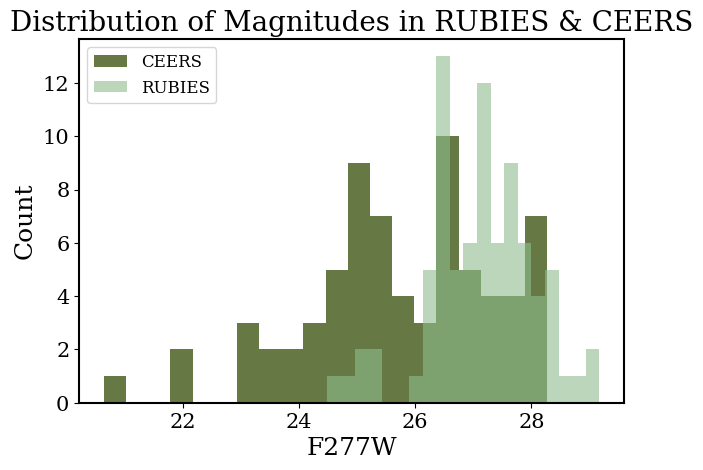

In [7]:

plt.figure()
plt.style.use('paper')  # Ensure this style exists or use 'default'
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['axes.linewidth'] = 1.5
plt.hist(flux[combined_matched_table['catalog'] == 'CEERS'], color='darkolivegreen', label='CEERS', alpha=0.9, bins=20)
plt.hist(flux[combined_matched_table['catalog'] == 'RUBIES'], color='darkseagreen', label='RUBIES', alpha=0.6, bins=20)
plt.title('Distribution of Magnitudes in RUBIES & CEERS')
plt.legend()
plt.xlabel('F277W')
plt.ylabel('Count')
plt.tight_layout()
plt.subplots_adjust(bottom=0.15) 
plt.show()

## to add F277W column as magnitudes in master RUBIES_and_CEERS_table

In [13]:
# import numpy as np
# from astropy.table import Table

# # Initialize a zeros array for the new flux column
# zeros_flux_array = np.zeros(len(RUBIES_and_CEERS_table))
# # Compute the flux values for the combined_matched_table
# flux_values = -2.5 * np.log10(combined_matched_table['FLUX_F277W_matched'] / 3631e9)

# # Find indices where filenames match between the two tables
# # Assuming 'filename' is the column in both tables that contains the filenames
# for i, filename in enumerate(RUBIES_and_CEERS_table['filename']):
#     matched_indices = np.where(combined_matched_table['filename'] == filename)[0]
#     if len(matched_indices) > 0:
#         # Assume the first match is the correct one (or handle duplicates as needed)
#         zeros_flux_array[i] = flux_values[matched_indices[0]]

# # Assign the populated flux array to the RUBIES_and_CEERS_table
# RUBIES_and_CEERS_table['F277W'] = zeros_flux_array
